# **INTELIGENCIA ARTIFICIAL (1INF24)**<br>
## **2024-2**


---

# **EXAMEN 1 - Parte 2**

**Indicaciones generales:**
- Duración: **100 minutos (1:40 min)**.
- Para responder las preguntas de esta parte <font color='red'>SOLO SE PERMITE LOS NOTEBOOKS DADOS EN CLASE</font>
- Es <font color='red'>OBLIGATORIO DESHABILITAR ASISTENCIA DE IA</font> (Tools->Settings->AI Assistant). De no hacerlo puede ser anulada su evaluacion. Se verificara ello en los  logs.  
- Cualquier indicio de plagio resultará en la anulación de la prueba.
- Subir el cuadernillo con el nombre **Examen1-Parte2_código.ipynb**, donde código es su código PUCP de 8 dígitos.  
- Se tomará en cuenta en la calificación la precision de la respuesta y el uso adecuado del lenguaje.

---

# Preparacion de datos y Construccion de Modelos de Regresion  (10 puntos)

Se disponde de un conjunto de datos (**CO2_Emissions_Canada.xlsx**), el cual contiene registros de vehiculos y sus emisiones de CO2. Los atributos que se tiene son los siguientes:

### ATRIBUTOS:
* Make = Marca del vehiculo,
* Model = Modelo del vehiculo,
* Vehicle Class = Clase del vehiculo dependiendo de su utilidad, capacidad y peso,
* Engine Size = Tamaño del motor en litros,
* Cylinders = Numero de cilindros,
* Transmission = Tipo de Transmision junto con Numero de Marchas. Tipos de transmision: A=Automatic, AM=Automated manual, AS=Automatic with select shift, AV=Continuously variable, M=Manual. Numero de marchas: 3-10  
* Fuel type = Tipo de combistible usado (X=Regular gasoline, Z=Premium gasoline, D=Diesel, E=Ethanol, N=Natural gas)
* Fuel Consumption City = Consumo de combustible en calles urbanas (L/100 km),
* Fuel Consumption Hwy = Consumo de de combustible en carreteras (L/100 km),
* Fuel Consumption Comb = Consumo de combustible combinado (55% en ciudad, 45% en carreteras). Es mostrado en L/100 km,
* Fuel Consumption Comb mpg = Consumo de combustible combinado  en millas por galon (mpg),
* CO2 Emissions(g/km) = Emisiones de CO2 en gramos por kilometro (Variable Target).

El conjunto de datos se ha tomado del sitio web oficial de datos abiertos del Gobierno de Canadá. Contiene datos de un período de 7 años y hay un total de 7385 filas y 12 columnas.  Con este dataset se requiere que usted haga el preprocesamiento y evaluacion de algoritmos de regresion para predecir la variable CO2 Emissions(g/km). **Es requisito que los modelos que usted evalue puedan servir para evaluar nuevos vehiculos, incluso si son de una marca y modelo que no se encuentra en el conjunto de datos proporcionado**

Se le pide que elabore y ejecute codigo en Python para realizar las siguientes tareas:

**1) Limpiar el dataset con el fin de obtener un conjunto de datos limpio. Los pasos que puede elegir aplicar aqui pueden ser: dropeos de columnas, dropeos de filas, imputacion de nulos. Cada paso elegido debe ser justificado.** (2 puntos)

Los valores duplicados son:  1103
El valor de la matriz antes de iniciar los valores duplicados son:  7385
El valor de la matriz antes de iniciar los valores duplicados son:  6282

Columnas del dataset:

Dataset limpio final:
(6282, 10)
Nulos restantes por columna:
 Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


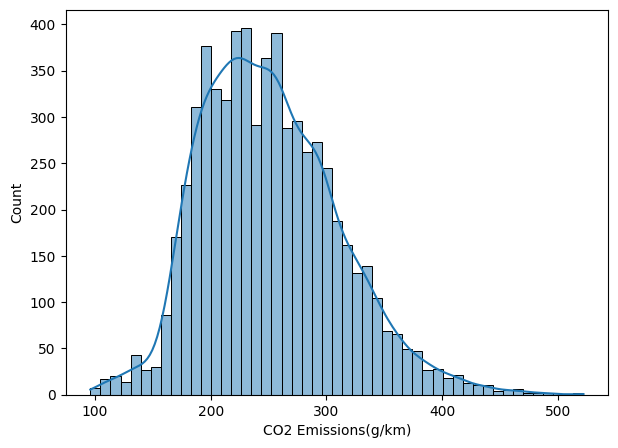

In [70]:
# RESPUESTA


#Librearías:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Lectura del csv.

df = pd.read_csv('CO2_Emissions_Canada.csv')

# df.info() # con esto verificamos que hay object, float e int.

#Verificación de nulos:
# print("Valores nulos por columna \n",df.isnull().sum()) # Con este comando verificamos cuantos valores duplicados tenemos en el dataset.

#Resultado: No hay valores nulos encontrados. Si los hubiera, tendríamos que hacer fillna para rellenarlos con la media o moda dependiendo de si es numérico o si es 'object'


#Verificación de duplicados:

duplicados = df.duplicated().sum()
print("Los valores duplicados son: ",duplicados)
print("El valor de la matriz antes de iniciar los valores duplicados son: ",df.shape[0])

if duplicados > 0:
  df.drop_duplicates(inplace=True)

print("El valor de la matriz antes de iniciar los valores duplicados son: ",df.shape[0])

# Visualizar nombres de columnas
print("\nColumnas del dataset:")

# list(df.columns) # Aqui verificamos las columnas.

#Una vez verificadas, eliminaremos 'Make' y 'Model' porque los modelos en adelante deben permitir predecir sin saber la marca y modelo.

df.drop(columns=['Make','Model'],inplace=True)

df.head() # Efectivamente, se eliminaron los duplicados

#Si existieran nulos:

# Si existieran nulos, se imputan según el tipo de variable
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == 'object':
            df[col].fillna(df[col].mode()[0], inplace=True)  # moda para categóricas
        else:
            df[col].fillna(df[col].median(), inplace=True)   # mediana para numéricas

#Ploteamos la variable objetivo:

plt.figure(figsize=(7,5))
sns.histplot(df['CO2 Emissions(g/km)'],kde=True)


print("\nDataset limpio final:")
print(df.shape)
print("Nulos restantes por columna:\n", df.isnull().sum())



**2) Genere e interprete un plot de correlaciones entre variables numericas. Si observa pares de variables con correlaciones elevadas (mayores a 0.96) escoja solo una de ellas** (1 punto)


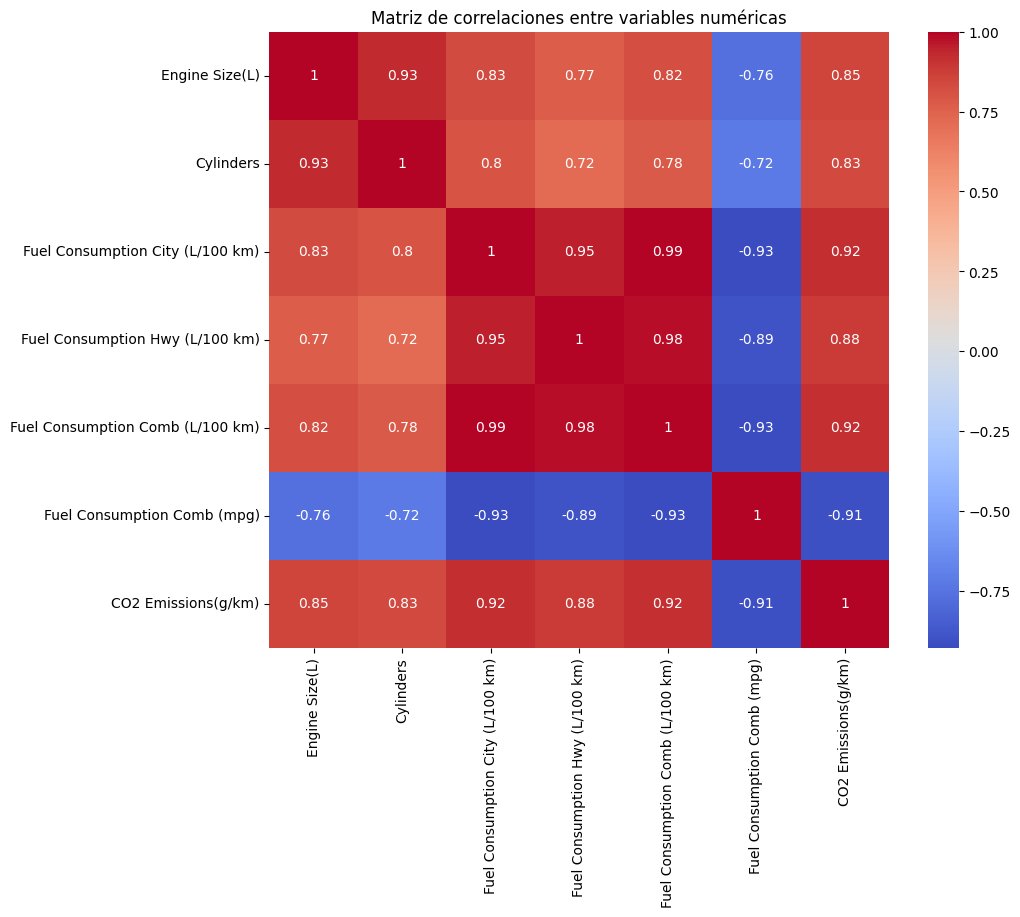

,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,COMPACT,2.0,4,AS5,Z,8.5,33,196
1,COMPACT,2.4,4,M6,Z,9.6,29,221
2,COMPACT,1.5,4,AV7,Z,5.9,48,136
3,SUV - SMALL,3.5,6,AS6,Z,11.1,25,255
4,SUV - SMALL,3.5,6,AS6,Z,10.6,27,244


In [71]:
# RESPUESTA

#Librerías:

import seaborn as sns
import matplotlib.pyplot as plt

#



num_cols = df.select_dtypes(include=('int64','float64')).columns
corr_matrix = df[num_cols].corr()



corr_matrix
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.title('Matriz de correlaciones entre variables numéricas')
plt.show()

# Una vez vista la matriz de correlaciones, eliminaremos , Fuel... City y Fuel... Hwy y nos quedaremos con "Comb" que representa la combinación de estos dos:


df.drop(columns=['Fuel Consumption City (L/100 km)','Fuel Consumption Hwy (L/100 km)'],inplace=True)
df.head()





**3) Codifique cada variable categorica con la codificacion adecuada (Label Encoding o OneHot Encoding). Justifique sus elecciones** (1 punto)


In [85]:
# RESPUESTA

from sklearn.preprocessing import LabelEncoder
import pandas as pd


# Verificamos las variables categóricas
cat_cols = df.select_dtypes(include='object').columns

df = pd.get_dummies(df,columns=cat_cols,drop_first=True)

#Se aplicó One-Hot Encoding porque todas las variables categóricas son nominales, es decir,
#representan categorías sin un orden natural (p. ej., no se puede decir que “Gasolina Regular” sea mayor o menor que “Diesel”).

#Usar One-Hot evita asignar valores numéricos que el modelo podría interpretar erróneamente como jerarquías.
#Además, se utilizó drop_first=True para evitar multicolinealidad (eliminar una columna redundante por cada grupo de categorías).


df.head(10)

,Engine Size(L),Cylinders,Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Vehicle Class_FULL-SIZE,Vehicle Class_MID-SIZE,Vehicle Class_MINICOMPACT,Vehicle Class_MINIVAN,Vehicle Class_PICKUP TRUCK - SMALL,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,2.0,4,8.5,33,196,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,2.4,4,9.6,29,221,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,1.5,4,5.9,48,136,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,True
3,3.5,6,11.1,25,255,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3.5,6,10.6,27,244,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
5,3.5,6,10.0,28,230,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
6,3.5,6,10.1,28,232,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7,3.7,6,11.1,25,255,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
8,3.7,6,11.6,24,267,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,True
9,2.4,4,9.2,31,212,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


**4) Dividir el dataset procesado en dos conjuntos: train y test. Usar 70% de los datos para train y 30% para test** (0 puntos)


In [92]:
# RESPUESTA

X = df.drop(columns=['CO2 Emissions(g/km)'])
y = df['CO2 Emissions(g/km)']

from sklearn.model_selection import train_test_split
# Luego, realizamos el train test:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

print('Training: %d ejemplos. Test: %d ejemplos' % (len(y_train), len(y_test)))



Training: 4397 ejemplos. Test: 1885 ejemplos


**5) Con el conjunto de train evalue en crosvalidación los siguientes algoritmos de regresión: Linear Regresion, Ridge Regresion, Lasso Regresion, ElasticNet Regresion, KNN (K=5) y Decision Tree Regresion (max_depth=20). Use 10 folds para la crosvalidación y como métrica de scoring use 'neg_mean_squared_error'. Muestre boxplots de los resultados de la crossvalidacion de todos los algoritmos evaluados y comente los resultados.** (2 puntos)  


LinearReg: -28.55162514531559 (9.766023765251779)
Ridge: -28.643847815050048 (9.139554874535921)
Lasso: -87.03519958670765 (8.81312418215829)
ElasticNet: -326.7554807253559 (28.231745694818503)
KNN5: -35.17069068130047 (12.062267028949766)
RegTrees: -26.04189794107932 (12.639601022562537)


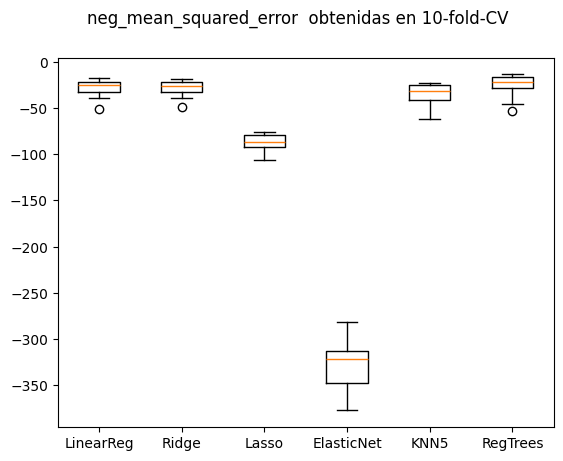

In [98]:
# RESPUESTA

#Librerías:
from sklearn.linear_model import LinearRegression   # para modelos de regresion lineal
from sklearn.linear_model import Ridge            # Ridge regression
from sklearn.linear_model import Lasso            # Lasso regression
from sklearn.linear_model import ElasticNet       # ElasticNet regression
from sklearn.neighbors import KNeighborsRegressor # Knn regression
from sklearn.tree import DecisionTreeRegressor    # Decision Trees regression
from sklearn.svm import SVR                       # Support Vector regression

from sklearn.model_selection import train_test_split  # para partir los datos en conjuntos de entrenamiento y validacion
from sklearn.model_selection import KFold  # para partir la data en k-folds
from sklearn.model_selection import cross_val_score   # para evaluar algoritmos en cross validacion

from sklearn.metrics import mean_squared_error, mean_absolute_error   # para manejar metricas de desempeño
from sklearn.metrics import explained_variance_score  # para hacer reportes de resultados de clasificacion
from sklearn.metrics import r2_score  # para manejar matrices de confusion


#

# Definimos el pool de algoritmos de ML a evaluar
algos = []
algos.append(('LinearReg', LinearRegression( )))
algos.append(('Ridge', Ridge( )))
algos.append(('Lasso', Lasso()))
algos.append(('ElasticNet', ElasticNet()))
algos.append(('KNN5', KNeighborsRegressor( n_neighbors=5 ) ))
algos.append(('RegTrees', DecisionTreeRegressor(max_depth=20)))

# Evaluamos cada pipeline de ML en estrategia de 10-fold-CV
results = []
names = []

# Evaluamos cada algoritmo de ML
results = []
names = []

# genera el particionamiento de 10 folds que seran usados en cada evaluacion
seed = 7
kfold = KFold( n_splits=10, random_state=seed, shuffle= True)  # especifica el particionador de datos a 10-folds CV

#  evalua cada algoritmo
for algoname, algo in algos:
    cv_results = cross_val_score(algo, X_train, y_train, cv=kfold, scoring='neg_mean_squared_error')  #r2 neg_mean_squared_error Estandar de sklearn: a mayor score, mejor modelo
    results.append(cv_results)
    names.append(algoname)
    print("{}: {} ({})".format(algoname, cv_results.mean(), cv_results.std()))

# Muestra graficamente los resultados de neg_mean_absolute_error  en crossvalidacion de los Algoritmos evaluados
fig = plt.figure()
fig.suptitle('neg_mean_squared_error  obtenidas en 10-fold-CV')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()


**6) Escoja el algoritmo con mejores resultados en el paso 5  y entrene un modelo final usando todos los datos de entrenamiento y evalúelo en la data separada para prueba (paso 4). Muestre un scatter plot de los valores reales vs los predichos en el conjunto de test y comente los resultados.** (1 puntos)  


Mean squared error: 22.422170669064144
Mean absolute error: 2.4291115952342115
Explained variance score: 0.9934581187993426
R2 score: 0.9934581090616608


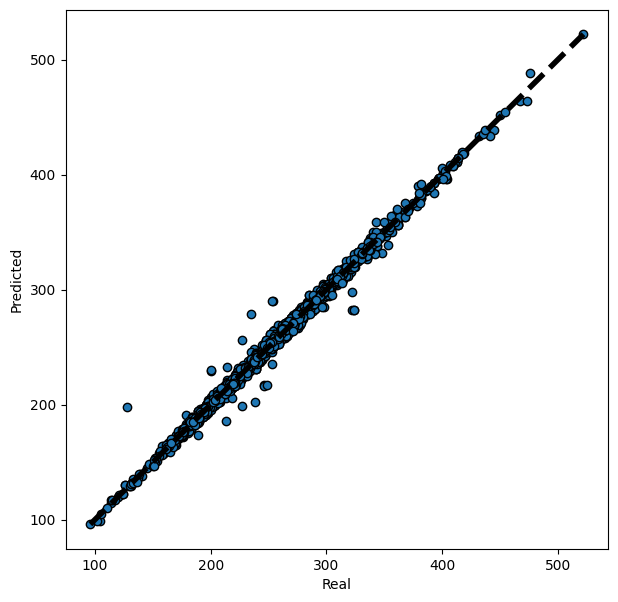

In [100]:
# RESPUESTA

# Reentrena modelo de regresion Trees con todos los datos de entrenamiento y lo prueba en el conjunto de test
model = DecisionTreeRegressor(max_depth=20) #  usar class_weight = 'balanced') para entrenar tomando en cuenta el desbalance
model.fit(X_train, y_train)

# predice el target en el conjunto de test
y_predicted = model.predict(X_test)

# El módulo metrics de sklearn provee métodos para calcular las métricas de desempeño
print("Mean squared error:", mean_squared_error(y_test, y_predicted))
print("Mean absolute error:", mean_absolute_error(y_test, y_predicted))
print("Explained variance score:", explained_variance_score(y_test, y_predicted))
print("R2 score:", r2_score(y_test, y_predicted))

fig, ax = plt.subplots( figsize=[7,7])
ax.scatter(y_test, y_predicted, edgecolors=(0, 0, 0))
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=4)
ax.set_xlabel('Real')
ax.set_ylabel('Predicted')
plt.show()

**7) Explique brevemente ¿por qué se hace crosvalidación en el conjunto de train para evaluar los algoritmos de regresión? ¿Por que no simplemente se entrena modelos con todo train y se los evalua con los datos de test?**  (2 puntos)


RESPUESTA: Se hace cross-validación en train para estimar de forma robusta el rendimiento de los modelos sin contaminar el conjunto test, que debe reservarse para la evaluación final e imparcial.


**8) Explique en sus palabras qué es la "maldicion de la dimensionalidad" y como se puede abordar. ¿Ese fenomeno existe en el presente problema?**   (1 puntos)

RESPUESTA: La maldición de la dimensionalidad aparece cuando hay muchas variables y pocos datos, dificultando el aprendizaje del modelo.
En este caso no se presenta, ya que el dataset tiene pocas variables y suficiente cantidad de observaciones. Si la hubiera, se puede aplicar PCA para resolver este caso.
